In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import pandas as pd

In [2]:

df = pd.DataFrame({
    "soil_moisture": [0.10, 0.15, 0.20, 0.25, 0.40, 0.60, 0.35, 0.18,
                      0.45, 0.05, 0.80, 0.27, 0.55, 0.70, 0.12, 0.30],
    "temperature_c": [34, 30, 26, 22, 28, 30, 19, 22,
                      35, 24, 33, 33, 21, 25, 20, 29],
    "sunlight_hours": [9, 8, 7, 4, 8, 10, 3, 10,
                       12, 5, 9, 11, 2, 6, 1, 9],
    "needs_water": [1, 1, 1, 0, 0, 0, 0, 1,
                    0, 1, 0, 1, 0, 0, 1, 1]
})

In [3]:
df

,soil_moisture,temperature_c,sunlight_hours,needs_water
0,0.10,34,9,1
1,0.15,30,8,1
2,0.20,26,7,1
3,0.25,22,4,0
4,0.40,28,8,0
5,0.60,30,10,0
6,0.35,19,3,0
7,0.18,22,10,1
8,0.45,35,12,0
9,0.05,24,5,1


In [4]:
X = df.drop('needs_water', axis=1)
X

,soil_moisture,temperature_c,sunlight_hours
0,0.10,34,9
1,0.15,30,8
2,0.20,26,7
3,0.25,22,4
4,0.40,28,8
5,0.60,30,10
6,0.35,19,3
7,0.18,22,10
8,0.45,35,12
9,0.05,24,5


In [5]:
y = df['needs_water']
y

0     1
1     1
2     1
3     0
4     0
5     0
6     0
7     1
8     0
9     1
10    0
11    1
12    0
13    0
14    1
15    1
Name: needs_water, dtype: int64

In [6]:
#min-max Scaling
X_min = X.min()
X_max = X.max()

X_scaled = (X - X_min) / (X_max - X_min + 1e-8)

In [7]:
X_scaled

,soil_moisture,temperature_c,sunlight_hours
0,0.066667,0.9375,0.727273
1,0.133333,0.6875,0.636364
2,0.200000,0.4375,0.545455
3,0.266667,0.1875,0.272727
4,0.466667,0.5625,0.636364
5,0.733333,0.6875,0.818182
6,0.400000,0.0000,0.181818
7,0.173333,0.1875,0.818182
8,0.533333,1.0000,1.000000
9,0.000000,0.3125,0.363636


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)), #input
        layers.Dense(8, activation='relu'), #hidden layer with 8 neurons
        layers.Dense(1, activation='sigmoid') #output(binary classification)
    ])

In [10]:
model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

In [11]:
# def create_model():
#     model = keras.Sequential([
#         layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
#         layers.Dense(1, activation='sigmoid')
#     ])
    
#     model.compile(
#         optimizer='adam',
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )
    
#     return model

> ***Train Separately:***

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 100, batch_size = 4, verbose = 1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9167 - loss: 0.5998 - val_accuracy: 0.7500 - val_loss: 0.6137
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9167 - loss: 0.5985 - val_accuracy: 0.7500 - val_loss: 0.6124
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9167 - loss: 0.5967 - val_accuracy: 0.7500 - val_loss: 0.6114
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9167 - loss: 0.5956 - val_accuracy: 0.7500 - val_loss: 0.6104
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9167 - loss: 0.5943 - val_accuracy: 0.7500 - val_loss: 0.6091
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9167 - loss: 0.5928 - val_accuracy: 0.7500 - val_loss: 0.6078
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9167 - loss: 0.5918 - val_accuracy: 0.7500 - val_loss: 0.6068
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9167 - loss: 0.5901 - val_accuracy: 0.7500 - val_loss:

1. **loss:**<br>
This is the training loss.<br>
It tells you how wrong your model’s predictions are on the training set, according to the loss function you chose (in your case: binary
cross-entropy).<br>
Lower is better.<br>
During training, the model tries to reduce this number by updating weights with gradient descent.

2. **accuracy:**<br>
This is the training accuracy.<br>
It tells you what fraction of training samples the model is correctly predicting.<br>
Example: If you have 100 samples and the model gets 80 correct → accuracy = 0.80 (80%).

3. **val_loss**<br>
This is the validation loss.<br>
After generalizing well or just memorizingion set (the split you gave with validation_data=...) and calculates the loss on that unseen data.<br>
This tells you whether your model is generalizing well or just memorizing the training data.

4. **val_accuracy**<br>
This is the validation accuracy.<br>
It’s the percentage of correct predictions on the validation set.<br>
If accuracy is high but val_accuracy is low → your model is probably overfitting (memorizing training but failing on new data).

**Where to pay attention:**
- loss & accuracy = how well model is doing on training data.
- val_loss & val_accuracy = how well model is doing on new unseen data.

> Always pay more attention to validation metrics because that shows how the model will behave in the real world.

---

Vanilla Gradient Descent:

In [ ]:
#Full Batch Gradient Descent:
# model_full = create_model()
# history_full = model_full.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=100,

#     batch_size=len(X_train),

#     verbose=1
# )

Stochastic Gradient Descent:

In [ ]:
#Stochastic Gradient Descent (batch_size = 1):
# model_sgd = create_model()
# history_sgd = model_sgd.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=100,

#     batch_size=1, 

#     verbose=1
# )

Mini-batch Gradient Descent:

In [ ]:
#Mini-batch Gradient Descent:
# model_mini = create_model()
# history_mini = model_mini.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=100,

#     batch_size=4,

#     verbose=1
# )

| Type       | Batch Size     | Behavior        |
| ---------- | -------------- | --------------- |
| Full Batch | = dataset size | Stable but slow |
| SGD        | 1              | Noisy but fast  |
| Mini-batch | 16–64        | Little noisy but best balance    |


---

### **Momentum** with SCD:
> Accelerates deep learning training by accumulating a moving average of past gradients, allowing the optimizer to navigate flat regions **faster and reduce oscillations(noise)** in narrow ravines

Simulation: https://share.google/OSX1eBa0sUFPieGIG

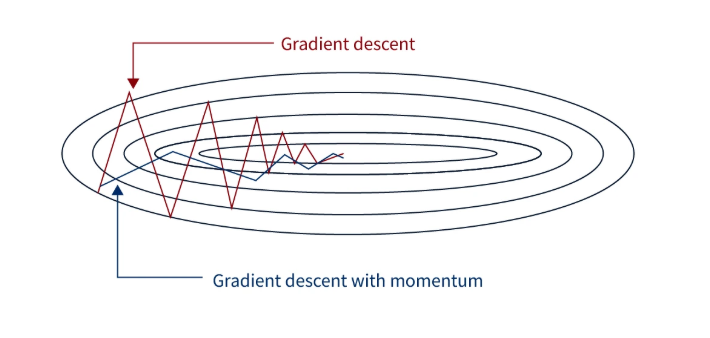

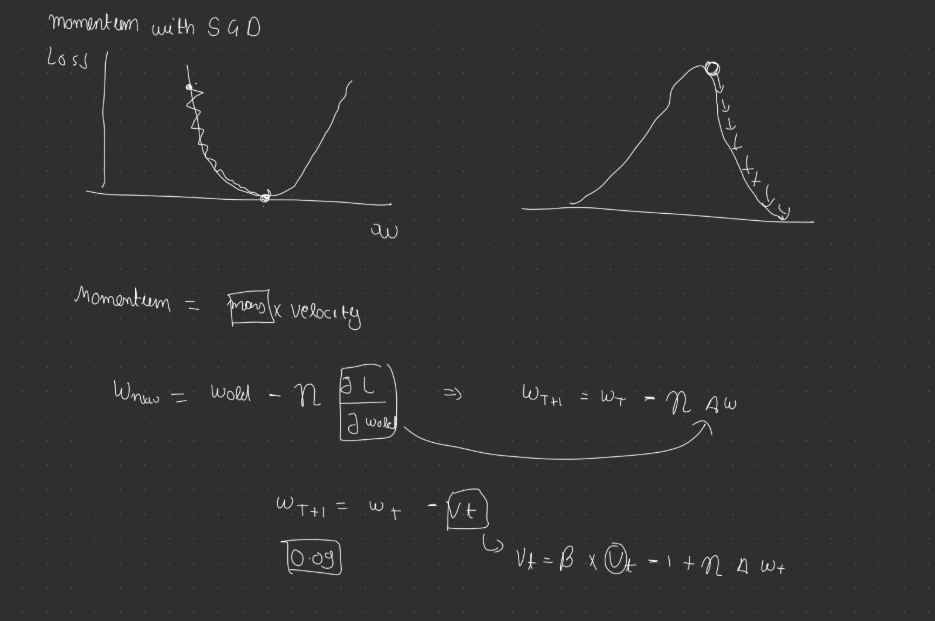

In [16]:
from tensorflow.keras import optimizers

In [ ]:
#optimizer = 'opt'
opt = optimizers.SGD(learning_rate=0.01, momentum=0.9)

### **AdaGrad** (Adaptive Gradient Descent):
> A gradient-based optimizer that improves Deep Learning training by **adapting the learning rate** for each parameter individually

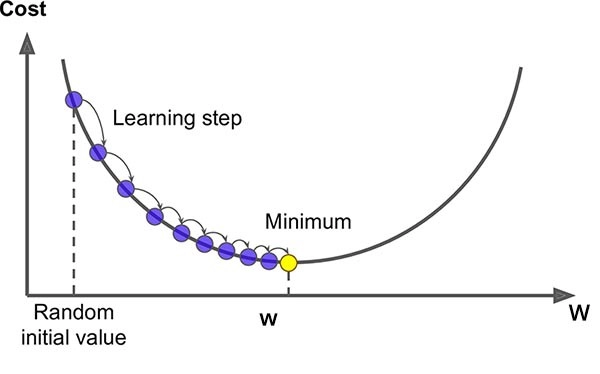

no momentum

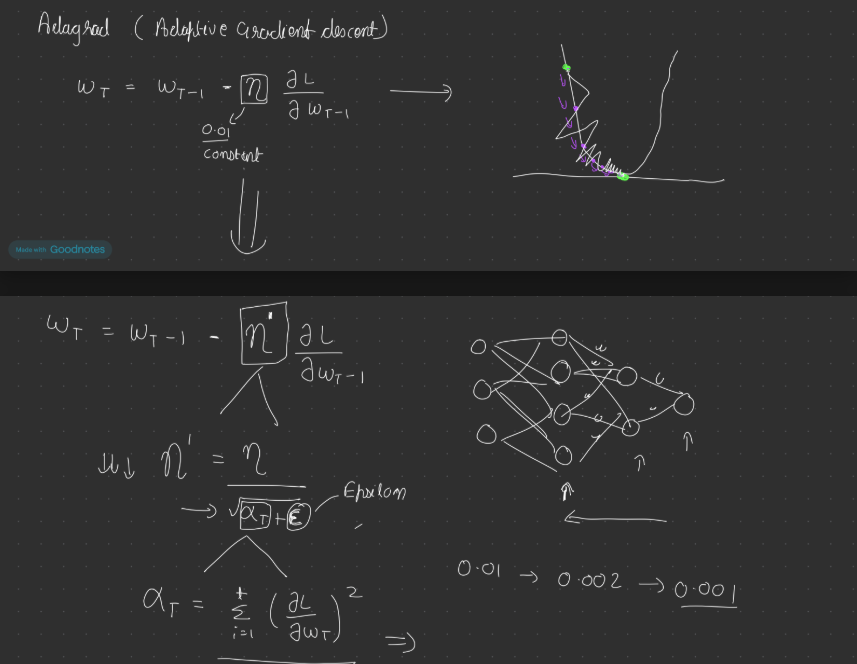

---

# **Adam Optimizer:** (AdaGrad + Momentum)
> a widely used algorithm in deep learning that **combines the benefits** of two other extensions of **stochastic gradient descent: Momentum** and the core idea of **AdaGrad** (as refined in RMSProp)

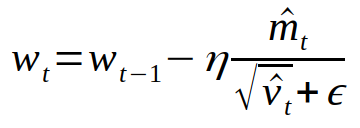

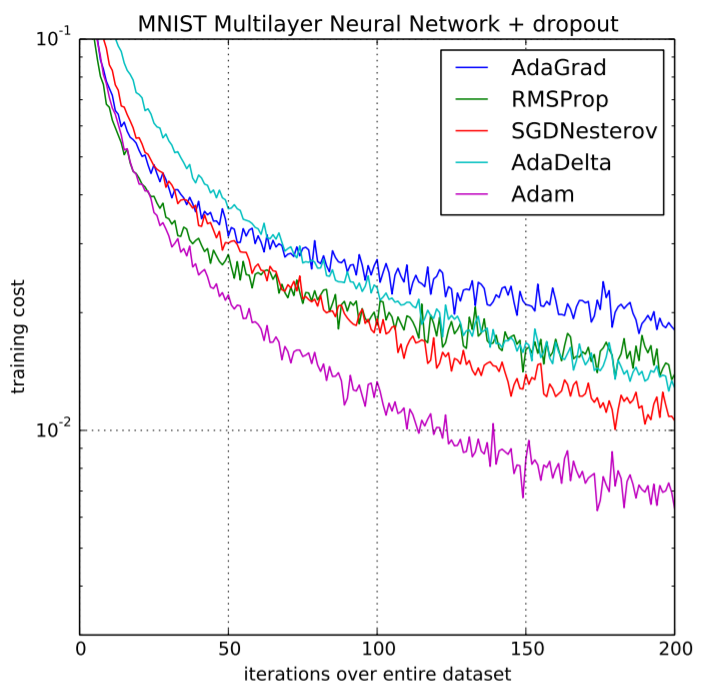